# **Import Dataset**

In [4]:
import pandas as pd

df1 = pd.read_csv('../../dataset-generation/cryst-unnormalized-5000ep-ppo-default-500.csv')
df2 = pd.read_csv('../../dataset-generation/cryst-unnormalized-5000ep-ppo-default-30000.csv')
df3 = pd.read_csv('../../dataset-generation/cryst-unnormalized-5000ep-random.csv')
print(df1.head(20))
print('-'*50)
print(df2.head(20))
print('-'*50)
print(df3.head(20))
print('-'*50)
print(df1.shape, df2.shape, df3.shape)

            mu0            mu1          mu2         C        CV         Ln  \
0   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
1   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
2   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
3   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
4   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
5   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
6   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
7   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
8   2206.455078   80213.414062   5138588.00  0.158856 -0.152808  36.020634   
9   2206.462402   80213.578125   5138600.50  0.158856 -0.152807  36.020599   
10  2206.467529   80213.687500   5138607.50  0.158856 -0.152806  36.020573   
11  2206.447510   80213.140625   5138570.50  0.158856 -0.152808 

In [5]:
df = pd.concat([df1, df2,df3], axis=0)
df

,mu0,mu1,mu2,C,CV,Ln,CV_SP,Ln_SP,mu3
0,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
1,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
2,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
3,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
4,1753.685913,4.881658e+04,3.005200e+06,0.159571,0.074865,27.503227,1.0,15.0,3.790643e+08
...,...,...,...,...,...,...,...,...,...
144995,336200.375000,5.059848e+06,2.459005e+08,0.081437,0.467194,14.716766,1.0,15.0,2.386137e+10
144996,347912.031250,5.142655e+06,2.469948e+08,0.080832,0.473923,14.448122,1.0,15.0,2.404313e+10
144997,349708.437500,5.175920e+06,2.474738e+08,0.080846,0.467637,14.467314,1.0,15.0,2.403895e+10
144998,344554.187500,5.065091e+06,2.451176e+08,0.081125,0.488102,14.367105,1.0,15.0,2.395515e+10


# **Scaling the dataset using MinMaxScaler**

In [13]:
from sklearn.preprocessing import MinMaxScaler
import joblib

X = df.drop(columns=['mu3','C', 'CV_SP', 'Ln_SP'])
y = df[['mu3','C']]

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y_scaled = pd.DataFrame(y_scaled, columns=y.columns, index=y.index)

joblib.dump(scaler_x, 'X_scaler_2.pkl')
joblib.dump(scaler_y, 'y_scaler_2.pkl')

['y_scaler_2.pkl']

In [14]:
print(X_scaled.columns)
print(y_scaled.columns)

Index(['mu0', 'mu1', 'mu2', 'CV', 'Ln'], dtype='str')
Index(['mu3', 'C'], dtype='str')


In [15]:
X.describe()

,mu0,mu1,mu2,CV,Ln
count,435000.000000,4.350000e+05,4.350000e+05,435000.000000,435000.000000
mean,150477.551029,2.640969e+06,1.383502e+08,0.274025,22.565072
std,124318.060625,1.892845e+06,9.100794e+07,0.224115,7.797074
min,1500.000000,2.300000e+04,1.800000e+06,-0.176087,14.135282
25%,18497.683594,5.657038e+05,4.099245e+07,0.173863,15.961856
50%,141452.781250,2.953382e+06,1.648912e+08,0.286172,19.739491
75%,269682.468750,4.494904e+06,2.251398e+08,0.405137,27.524300
max,355471.875000,5.260476e+06,2.508301e+08,1.000000,40.058300


# **Split Data**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_scaled,test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(326250, 5) (108750, 5) (326250, 2) (108750, 2)


# **Training XGBoost model**

In [18]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score

#Define the model
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

# checking the model rmse and r2
y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_pred=y_pred, y_true=y_test)
print(f"RMSE: {rmse}")
print(f'R2: {r2}')

#Save the model
xgb_model.save_model("xgb_2.json")

RMSE: 0.0013471981510519981
R2: 0.9999865293502808


<Axes: title={'center': 'Feature Importance(Cover)'}, xlabel='Importance score', ylabel='Features'>

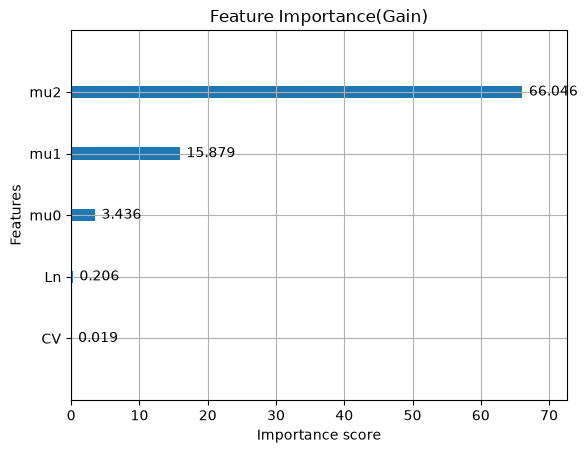

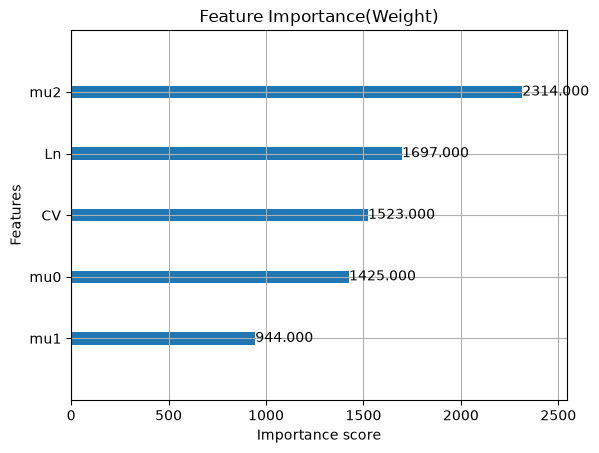

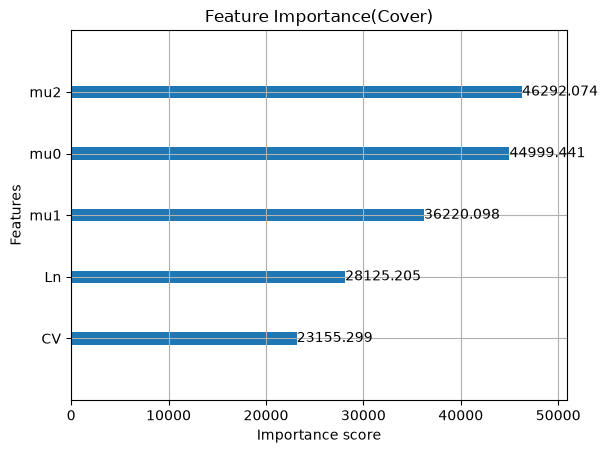

In [19]:
from xgboost import plot_importance

plot_importance(xgb_model, importance_type='gain', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Gain)') # Or weight, cover
plot_importance(xgb_model, importance_type='weight', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Weight)') # Or weight, cover
plot_importance(xgb_model, importance_type='cover', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Cover)') # Or weight, cover

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# 2. Define Model and Search Space
xgb_model = xgb.XGBRegressor()
param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5)
}

# 3. Configure Randomized Search
search = RandomizedSearchCV(xgb_model, param_dist, n_iter=100, cv=5, n_jobs=-1)

# 4. Fit and Evaluate
search.fit(X_train, y_train)
print("Best Params:", search.best_params_)
print("Best Score:", search.best_score_)

from sklearn.metrics import root_mean_squared_error

y_pred = search.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

Best Params: {'colsample_bytree': np.float64(0.9720208587187729), 'learning_rate': np.float64(0.08817704152702564), 'max_depth': 9, 'n_estimators': 480, 'subsample': np.float64(0.6082882419762725)}
Best Score: 0.9999881744384765
RMSE: 0.0012978191953152418


In [21]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred = search.best_estimator_.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RMSE: 0.0012978191953152418
R2: 0.9999874830245972
